# **PROYECTO ALMA (MUSICA)**

Es una aplicación que conecta poesía universal con datos técnicos musicales de Spotify para recomendar canciones basadas en el estado emocional del usuario.

Las canciones vinculadas a emociones poéticas universales y de alta intensidad afectiva (como el amor o la pasión) registran niveles de popularidad promedio significativamente más altos en Spotify que aquellas asociadas a estados introspectivos o de melancolía. Asimismo, se asume que los artistas con mayor cantidad de seguidores en el mercado global concentran su repertorio en temáticas orientadas a la sanación y la resiliencia emocional.

Entonces, ¿Cómo se relacionan las etiquetas emocionales de la poesía universal con el éxito comercial (popularidad de la canción y alcance del artista) en la plataforma de Spotify?

**Librerias usadas**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Carga de datos**

In [2]:
df_spotify = pd.read_csv('spotify_data clean.csv')
df_poesia = pd.read_csv('poesia_musica_sentimientos.csv', on_bad_lines='skip')


# **1. EDA del Dataset de Spotify**

**Información general:**

In [3]:
print(df_spotify.shape)


(8582, 15)


El dataset de Spotify contiene 8.582 registros y 15 variables.

Esto indica que contamos con una cantidad suficiente de observaciones para realizar análisis descriptivos y explorar relaciones entre la popularidad de las canciones, los artistas y las emociones asociadas posteriormente en el proyecto.

**Tipos de datos:**

In [4]:
print(df_spotify.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8582 entries, 0 to 8581
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   track_id            8582 non-null   object 
 1   track_name          8582 non-null   object 
 2   track_number        8582 non-null   int64  
 3   track_popularity    8582 non-null   int64  
 4   explicit            8582 non-null   bool   
 5   artist_name         8579 non-null   object 
 6   artist_popularity   8582 non-null   int64  
 7   artist_followers    8582 non-null   int64  
 8   artist_genres       5221 non-null   object 
 9   album_id            8582 non-null   object 
 10  album_name          8582 non-null   object 
 11  album_release_date  8582 non-null   object 
 12  album_total_tracks  8582 non-null   int64  
 13  album_type          8582 non-null   object 
 14  track_duration_min  8582 non-null   float64
dtypes: bool(1), float64(1), int64(5), object(8)
memory usag

La columna `artist_genres` concentra la mayor cantidad de datos faltantes, por lo que será necesario evaluar su limpieza.

La mayoría de las variables se encuentran completas, lo que indica una buena calidad inicial de los datos.

**Estadisticas**




Se calculan estadísticas descriptivas de las variables numéricas para conocer su distribución, rangos de valores y comportamiento general dentro del dataset.


In [5]:
df_spotify.describe()

,track_number,track_popularity,artist_popularity,artist_followers,album_total_tracks,track_duration_min
count,8582.000000,8582.000000,8582.000000,8.582000e+03,8582.000000,8582.000000
mean,5.772547,52.356211,69.730016,2.403472e+07,13.789443,3.492805
std,6.052792,23.816076,19.645979,3.803180e+07,11.887131,1.057970
min,1.000000,0.000000,0.000000,0.000000e+00,1.000000,0.070000
25%,1.000000,39.000000,60.000000,4.623200e+05,6.000000,2.880000
50%,4.000000,58.000000,74.000000,6.105547e+06,13.000000,3.445000
75%,9.000000,71.000000,84.000000,2.725255e+07,17.000000,3.990000
max,102.000000,99.000000,100.000000,1.455421e+08,181.000000,13.510000


La distribución de seguidores no es homogénea, ya que un pequeño grupo de artistas con audiencias extremadamente grandes incrementa significativamente el promedio general.

**Búsqueda de valores nulos:**

In [6]:
df_spotify.isnull().sum()

,0
track_id,0
track_name,0
track_number,0
track_popularity,0
explicit,0
artist_name,3
artist_popularity,0
artist_followers,0
artist_genres,3361
album_id,0


**Boxplot popularidad del artista**

Se analiza la dispersión y la simetría de la popularidad de los artistas, identificando visualmente la mediana, el rango intercuartílico y los valores atípicos.

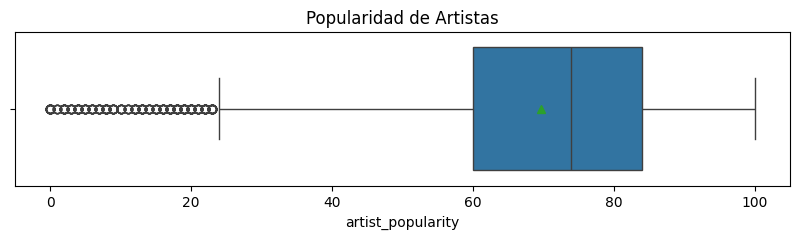

In [7]:
plt.figure(figsize=(10,2))
sns.boxplot(
    x=df_spotify["artist_popularity"],
    showmeans=True
)

plt.title("Popularidad de Artistas")
plt.show()

Para entender rápidamente el perfil general de los artistas en el dataset. El boxplot nos reveló que la mayoría son artistas consolidados, pero también nos alertó que existe una gran cantidad de artistas con popularidad inusualmente baja (outliers a la izquierda) que están alterando el promedio

**Histograma por popularidad de la canción**

Se grafica la frecuencia de las canciones según su nivel de popularidad (track_popularity), evaluando la forma de la distribución y las zonas de mayor concentración con la curva de densidad (KDE).


<Axes: xlabel='track_popularity', ylabel='Count'>

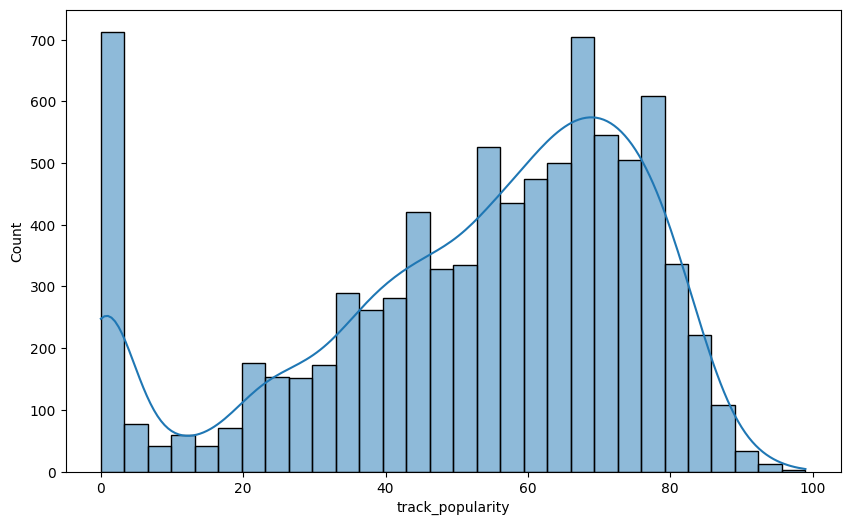

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(df_spotify['track_popularity'], bins=30, kde=True)

Para entender el comportamiento de la variable e identificar anomalías. Al revelar una distribución bimodal con un pico masivo en el valor cero, el histograma nos da la evidencia gráfica de que el dataset contiene ruido.

**Distribución de seguidores**

Se evalúa el volumen de seguidores de los artistas (artist_followers) a lo largo de una escala lineal completa.

<Axes: xlabel='artist_followers', ylabel='Count'>

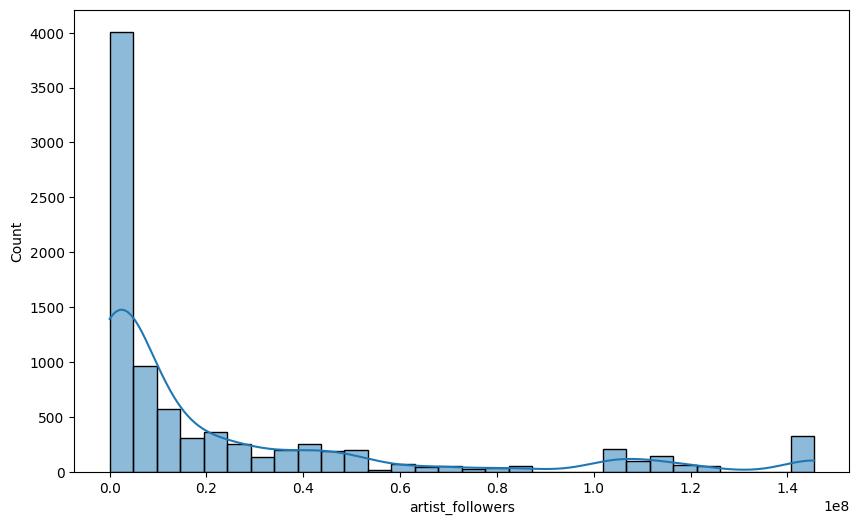

In [16]:
plt.figure(figsize=(10, 6))
sns.histplot(df_spotify['artist_followers'], bins=30, kde=True)

Esto se utiliza para diagnosticar problemas de escala. El gráfico demuestra que la variable sufre de un sesgo positivo extremo, donde el 99% de los artistas quedan "aplastados" visualmente cerca del cero debido a un puñado de grandes estrellas globales.

# **2. EDA del Dataset de emociones**

**Información general:**

In [10]:
df_poesia.shape

(99, 13)

In [11]:
df_poesia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   99 non-null     int64 
 1   autor                99 non-null     object
 2   nacionalidad         99 non-null     object
 3   epoca                99 non-null     object
 4   tipo_autor           99 non-null     object
 5   sentimiento          99 non-null     object
 6   emocion_tag          99 non-null     object
 7   frase_motivacional   99 non-null     object
 8   cancion_recomendada  99 non-null     object
 9   artista_cancion      99 non-null     object
 10  genero_musical       99 non-null     object
 11  año_cancion          99 non-null     object
 12  por_que_combina      99 non-null     object
dtypes: int64(1), object(12)
memory usage: 10.2+ KB


**Búsqueda de valores nulos:**

In [12]:
df_poesia.isnull().sum()

,0
id,0
autor,0
nacionalidad,0
epoca,0
tipo_autor,0
sentimiento,0
emocion_tag,0
frase_motivacional,0
cancion_recomendada,0
artista_cancion,0


**Emociones más frecuentes:**

Se aplica el método .value_counts() sobre la columna categórica emocion_tag. El resultado devuelve un total de 82 categorías únicas (rows), donde las etiquetas más repetidas apenas alcanzan entre 2 y 4 frecuencias.

In [13]:
df_poesia['emocion_tag'].value_counts()

,count
emocion_tag,
amor,4
pasión,3
asombro,3
resistencia,3
rebeldía,2
...,...
lenguaje,1
creación,1
paz,1


Sirve para identificar la alta cantidad de valores únicos de la variable. Al ver que existen 82 emociones distintas con muy pocas repeticiones cada una, el análisis nos advierte que los datos están demasiado dispersos.

**Histograma: Frecuencia de emociones en la poesía**

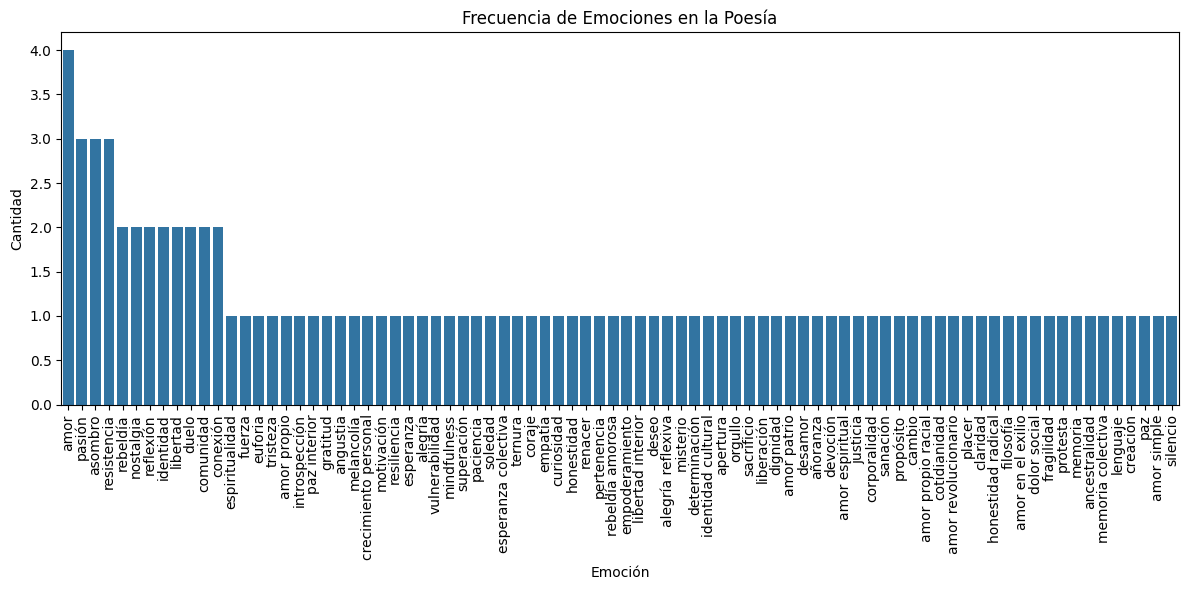

In [14]:
plt.figure(figsize=(12, 6))
sns.barplot(x=df_poesia['emocion_tag'].value_counts().index, y=df_poesia['emocion_tag'].value_counts().values)
plt.title('Frecuencia de Emociones en la Poesía')
plt.xlabel('Emoción')
plt.ylabel('Cantidad')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Se presenta un gráfico de barras que ordena de mayor a menor las frecuencias de la variable emocion_tag. Visualmente, se aprecia una caída drástica despues de las primeras cuatro barras. Esto sirve para evidenciar gráficamente el impacto de la alta cantidad de valores únicos, demostrando visualmente por qué es obligatorio agrupar las categorías en la siguiente etapa de limpieza.


**Histograma: Autores más frecuentes, con más registros**

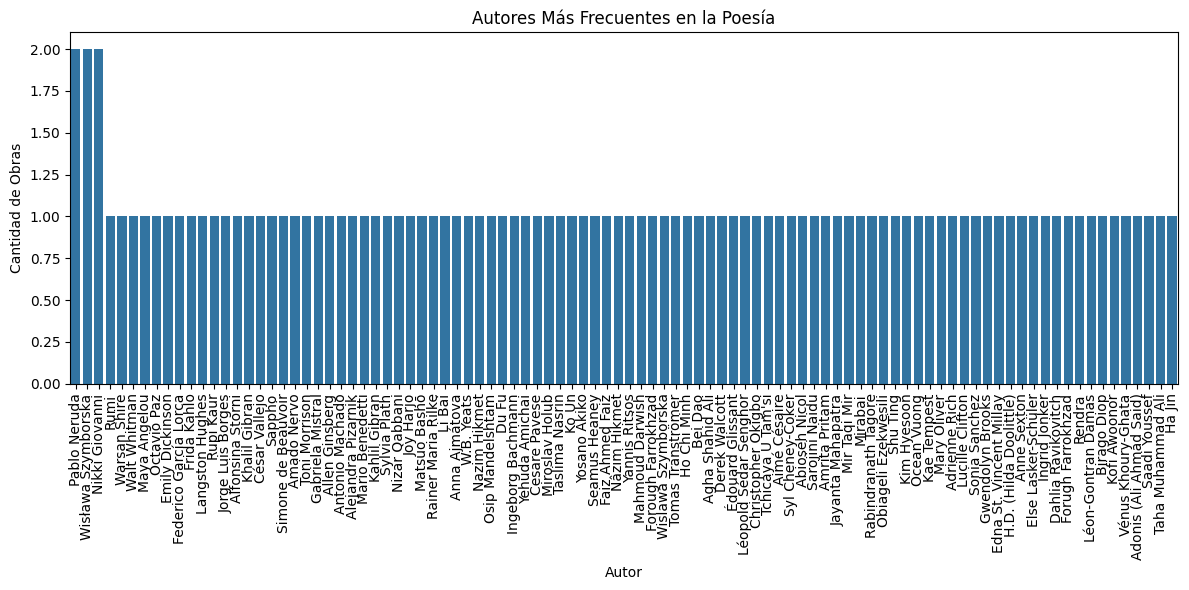

In [15]:
plt.figure(figsize=(12, 6))
sns.barplot(x=df_poesia['autor'].value_counts().index, y=df_poesia['autor'].value_counts().values)
plt.title('Autores Más Frecuentes en la Poesía')
plt.xlabel('Autor')
plt.ylabel('Cantidad de Obras')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Confirma que la variable autor sufre una fragmentación extrema (casi todos tienen un conteo de 1). Esto sirve para demostrar que el dataset es una colección muy diversa de autores individuales, lo que técnicamente descarta la posibilidad de modelar o cruzar datos a nivel de autor específico.